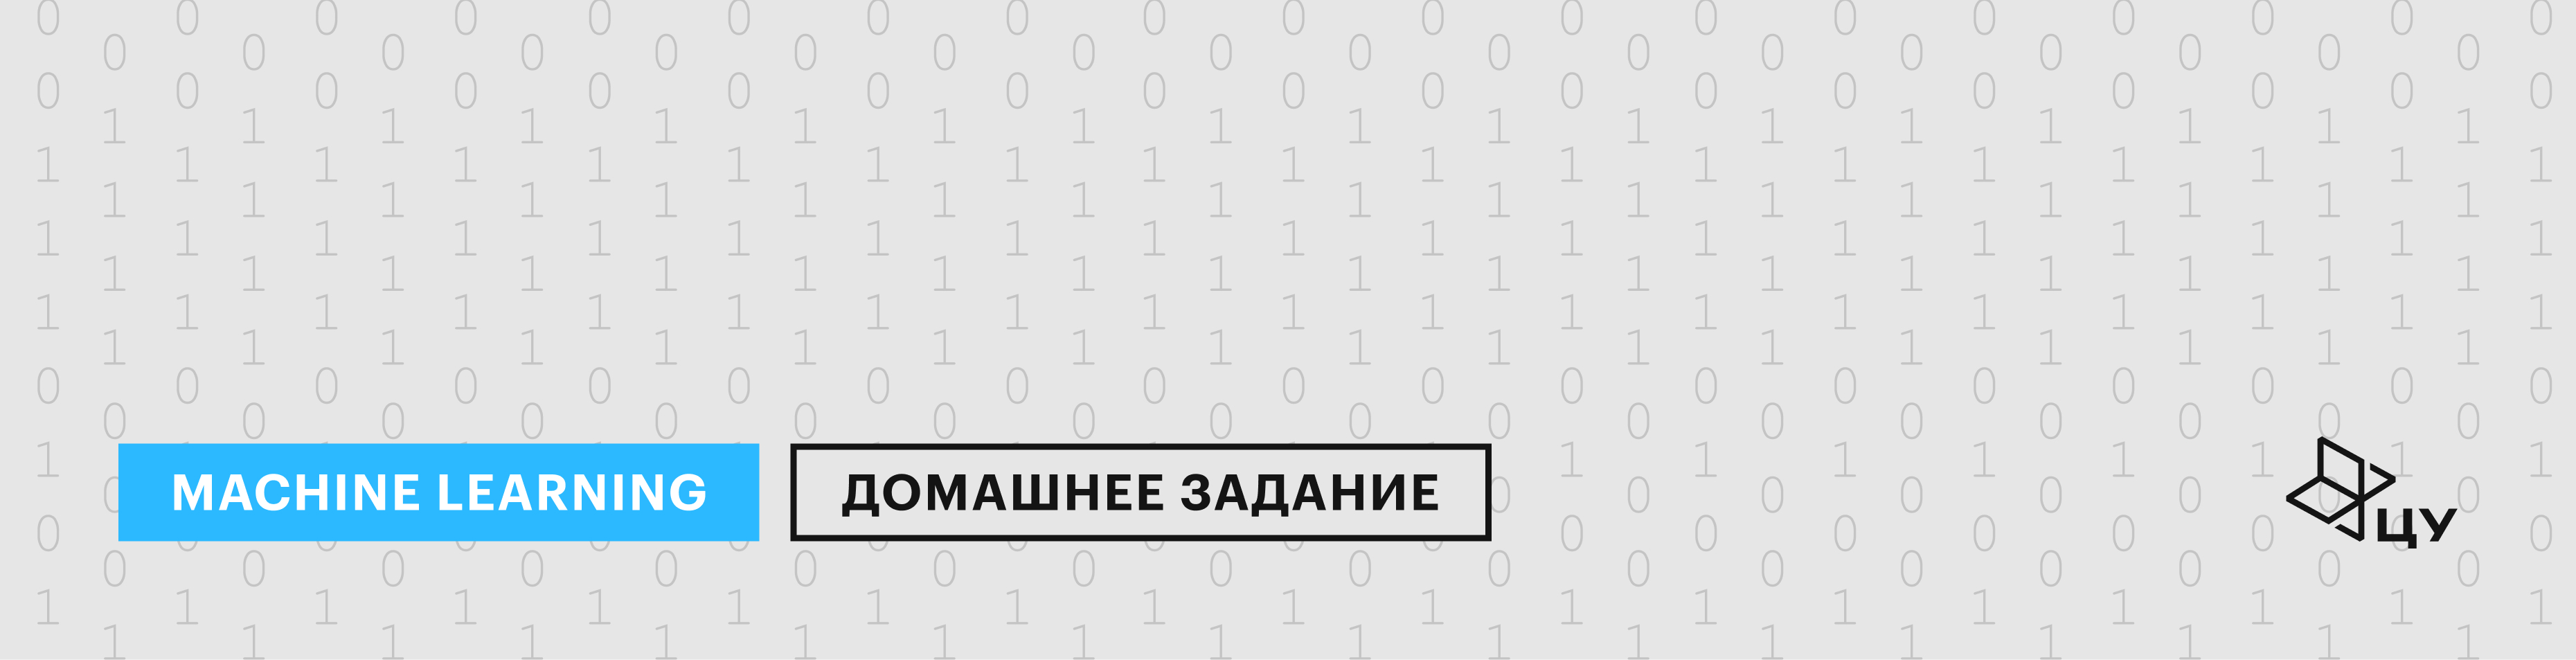

# Задание на мультиколлинеарность в ансамблях деревьев

Представьте типичную задачу из продукта/маркетинга/рисков: мы строим модель (например, для прогноза оттока, вероятности покупки или риска дефолта) и собираем десятки поведенческих и финансовых фичей. Часто среди них оказываются **почти дубликаты** — метрики, посчитанные похожими способами (например, *revenue_last_7d* и *revenue_last_8d*, *clicks_web* и *clicks_total*, *score_v1* и *score_v2*).

Есть популярный миф: «деревьям и их ансамблям всё равно на мультиколлинеарность».

В этой домашке мы на синтетическом примере посмотрим, как мультиколлинеарные признаки могут “делить” важность между собой в Random Forest и бустинге и почему это важно, когда модель используют для принятия решений.

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
import numpy as np
import pandas as pd
import math

rng = np.random.default_rng(seed=121)
random_state = 121
n_features = 10
n_samples = 20_000

# создадим датасет для классификации
x, y = make_classification(n_samples=n_samples, random_state=random_state, n_features=n_features)
df = pd.DataFrame(x, columns=[f'feature_{k}' for k in range(n_features)])
df['target'] = y

Смоделируем ситуацию «два почти одинаковых KPI»: добавим пару сильно коррелированных фичей (как бывает, когда один показатель — чуть более шумная версия другого).

In [2]:
df['golden_feature_1'] = df['target'] + rng.normal(size = len(y), scale = 0.4) # здесь шума добавили побольше -- фича будет послабее
df['golden_feature_2'] = df['target'] + df['golden_feature_1']  + rng.normal(size = len(y), scale = 0.35)#  здесь шума добавили поменьше -- фича будет посильнее

In [4]:
df.head(5)

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,target,golden_feature_1,golden_feature_2
0,-0.412080,1.998709,1.117675,1.069537,-0.876803,-0.985517,-0.286545,-0.613936,-0.826826,0.323063,1,0.902190,2.602104
1,1.278354,-1.858326,0.962436,0.052384,-1.150387,-0.969355,-0.365569,-0.295837,-0.754967,0.109132,1,0.768796,0.971733
2,0.066851,0.966767,0.927257,1.034021,-0.153914,0.554798,1.113124,-0.213582,-0.197318,-2.217828,1,1.103969,2.037110
3,1.194469,-2.208375,0.835247,1.292408,-0.655211,0.869960,1.367068,-1.087738,-0.045926,1.045615,1,0.569441,1.230124
4,1.300640,-0.034240,0.917948,1.350192,-0.480994,1.075267,1.619722,1.466392,-0.008044,0.077772,1,1.587566,2.269506


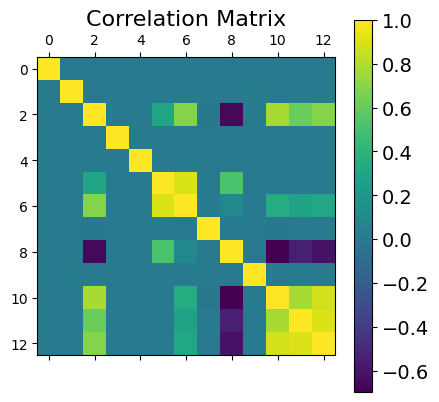

In [3]:
import matplotlib.pyplot as plt

plt.matshow(df.corr())
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.title('Correlation Matrix', fontsize=16)
plt.show()

Посмотрим на корреляции, как на этапе EDA: нас интересует блок, где находятся новые признаки и таргет.

<Axes: >

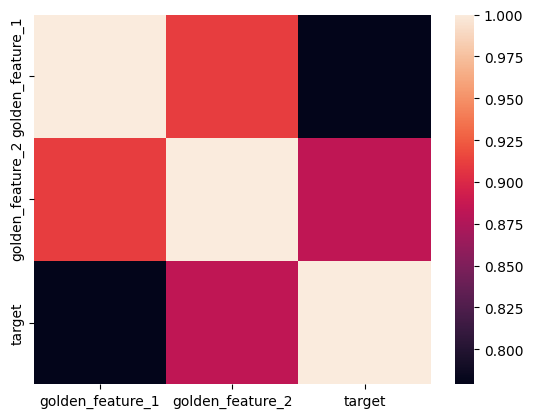

In [5]:
import seaborn as sns
corr = df[['golden_feature_1','golden_feature_2','target']].corr()
sns.heatmap(corr,
            xticklabels=corr.columns.values,
            yticklabels=corr.columns.values)

Обе *golden features* сильно скоррелированы между собой и с таргетом (так и задумано) — это и есть ситуация мультиколлинеарности/почти‑дубликатов.

## Random Forest

Обучим RandomForest и посмотрим на важности признаков.

А что, если два признака почти одинаковые и оба «хорошо объясняют таргет», то **какой из них модель назовёт главным драйвером?**

Как думаете, где окажутся по важности эти две сильно коррелированные между собой фичи?

In [6]:
from sklearn.ensemble import RandomForestClassifier

In [7]:
rf = RandomForestClassifier(n_estimators = 100, max_depth = 20, max_features = 0.5, random_state = random_state)
rf.fit(df.drop('target', axis = 1), y)

RandomForestClassifier(max_depth=20, max_features=0.5, random_state=121)

In [8]:
from tabulate import tabulate
from operator import itemgetter
t = []
for feature, importance in zip(df.drop('target', axis = 1).columns, rf.feature_importances_):
  t.append([feature, importance])
t = sorted(t, reverse = True, key = itemgetter(1))
print(tabulate(t, headers = ['Признак', 'Важность']))

Признак             Важность
----------------  ----------
golden_feature_2  0.607862
feature_2         0.176073
golden_feature_1  0.114753
feature_8         0.0741608
feature_6         0.0101138
feature_5         0.00778537
feature_0         0.00179993
feature_3         0.00170889
feature_7         0.00146428
feature_9         0.00145848
feature_4         0.00143497
feature_1         0.00138557


На практике это выглядит «неожиданно»: фича, которая очевидно связана с таргетом, может оказаться не на первом месте.

### Задание 3.1
Сохранится ли данный эффект при изменении параметра max_features? Продемонстрируйте это на собственном коде (вставьте ваш код ниже).

In [10]:
#INSERT YOUR CODE HERE
rf = RandomForestClassifier(n_estimators = 100, max_depth = 20, max_features = 0.9, random_state = random_state)
rf.fit(df.drop('target', axis = 1), y)
t = []
for feature, importance in zip(df.drop('target', axis = 1).columns, rf.feature_importances_):
  t.append([feature, importance])
t = sorted(t, reverse = True, key = itemgetter(1))
print(tabulate(t, headers = ['Признак', 'Важность']))

Признак             Важность
----------------  ----------
golden_feature_2  0.835539
feature_2         0.102261
feature_8         0.042239
feature_5         0.00473362
golden_feature_1  0.00371812
feature_6         0.00256499
feature_0         0.00169325
feature_3         0.00163647
feature_4         0.00143691
feature_1         0.00140603
feature_9         0.00140039
feature_7         0.00137217


### Вопрос для теста:
Выберите правильный вариант ответа на основании выполненного кода выше.
На каком месте окажется `golden_feature_1` при `max_features = 0.9`?

1. втором
2. третьем
3. четвертом
4. пятом
5. восьмом

**Ответ:** 4 (на пятом месте)

Хотя простая корреляционная матрица дает другие числа

In [11]:
df[['golden_feature_1','golden_feature_2','target']].corr()

,golden_feature_1,golden_feature_2,target
golden_feature_1,1.000000,0.910394,0.779165
golden_feature_2,0.910394,1.000000,0.883246
target,0.779165,0.883246,1.000000


Как дополнительно проверить, что `golden_feature_1` реально важна, а не просто проиграла дубликату в распределении важности?

Убрать почти‑дубликат и посмотреть, как перераспределится importance и качество!

### Задание 3.2
Обучите модель Random Forest без фичи `golden_feature_2`. Продемонстрируйте результат на собственном коде (вставьте ваш код ниже).

In [12]:
# INSERT YOUR CODE HERE
rf = RandomForestClassifier(n_estimators = 100, max_depth = 20, max_features = 0.9, random_state = random_state)
rf.fit(df.drop(['target', 'golden_feature_2'], axis = 1), y)
t = []
for feature, importance in zip(df.drop('target', axis = 1).columns, rf.feature_importances_):
  t.append([feature, importance])
t = sorted(t, reverse = True, key = itemgetter(1))
print(tabulate(t, headers = ['Признак', 'Важность']))

Признак             Важность
----------------  ----------
feature_2         0.605594
golden_feature_1  0.215889
feature_8         0.131145
feature_5         0.0130605
feature_6         0.00774722
feature_0         0.00467528
feature_4         0.00464695
feature_9         0.00454185
feature_7         0.00430285
feature_1         0.00422526
feature_3         0.00417155


### Вопрос для теста:
Выберите правильный вариант ответа на основании выполненного кода выше.
На каком месте по важности окажется `golden_feature_1`, если обучить Random Forest с `max_features = 0.9` на датасете **без** `golden_feature_2`?

1. первом
2. втором
3. третьем
4. четвертом
5. пятом
6. восьмом

**Ответ:** 2

## Extremal Gradient Boosting

Убедимся, что в бустинге при подвыборе признаков на деревьях/узлах эффект «дележа важности» тоже проявляется.

In [13]:
from xgboost import XGBClassifier
xgb = XGBClassifier(learning_rate=0.1, max_depth=6, n_estimators=100, colsample_bytree = 0.5, random_state = 43)

In [14]:
xgb.fit(df.drop('target', axis = 1), y)
t = []
for feature, importance in zip(df.drop('target', axis = 1).columns, xgb.feature_importances_):
  t.append([feature, importance])
t = sorted(t, reverse = True, key = itemgetter(1))
print(tabulate(t, headers = ['Признак', 'Важность']))

Признак             Важность
----------------  ----------
golden_feature_2  0.619467
feature_2         0.221745
feature_8         0.0638065
golden_feature_1  0.0492883
feature_6         0.0170231
feature_5         0.0134591
feature_9         0.00279441
feature_3         0.0027107
feature_7         0.00263437
feature_4         0.00243511
feature_0         0.00234785
feature_1         0.00228789


### Задание 3.3
Повторите эксперимент аналогично модели Random Forest. Продемонстрируйте результаты на собственном коде.

In [15]:
# INSERT YOUR CODE HERE
xgb = XGBClassifier(learning_rate=0.1, max_depth=6, n_estimators=100, colsample_bytree = 1, random_state = 43)
xgb.fit(df.drop('target', axis = 1), y)
t = []
for feature, importance in zip(df.drop('target', axis = 1).columns, xgb.feature_importances_):
  t.append([feature, importance])
t = sorted(t, reverse = True, key = itemgetter(1))
print(tabulate(t, headers = ['Признак', 'Важность']))

Признак             Важность
----------------  ----------
golden_feature_2  0.835641
feature_8         0.0562887
feature_2         0.055019
feature_5         0.0133256
feature_6         0.00698487
golden_feature_1  0.00582277
feature_3         0.00516934
feature_9         0.00475428
feature_1         0.00455164
feature_0         0.00439369
feature_7         0.00408448
feature_4         0.00396448


### Вопрос для теста:
Выберите правильный вариант ответа на основании выполненного кода выше.
На каком месте окажется `golden_feature_1` при `colsample_bytree = 1.0`?

1. втором
2. третьем
3. четвертом
4. пятом
5. шестом
6. восьмом

**Ответ:** 5(на шестом)

### Задание 3.4
Теперь посмотрим, что произойдёт без «подруги» — фичи `golden_feature_2` (как если бы мы почистили датасет от дубликатов/слишком похожих метрик). Продемонстрируйте это на собственном коде.

In [16]:
# INSERT YOUR CODE HERE
xgb = XGBClassifier(learning_rate=0.1, max_depth=6, n_estimators=100, colsample_bytree = 1, random_state = 43)
xgb.fit(df.drop(['target', 'golden_feature_2'], axis = 1), y)
t = []
for feature, importance in zip(df.drop('target', axis = 1).columns, xgb.feature_importances_):
  t.append([feature, importance])
t = sorted(t, reverse = True, key = itemgetter(1))
print(tabulate(t, headers = ['Признак', 'Важность']))

Признак             Важность
----------------  ----------
feature_2         0.72251
feature_8         0.11547
golden_feature_1  0.101766
feature_5         0.0138126
feature_6         0.0092117
feature_0         0.00706574
feature_1         0.00642251
feature_3         0.00633196
feature_9         0.00609246
feature_7         0.00598582
feature_4         0.00533143


### Вопрос для теста:
На каком месте окажется `golden_feature_1` при обучении на датасете **без** `golden_feature_2` с параметром `colsample_bytree = 1.0`?

1. первом
2. втором
3. третьем
4. четвертом
5. пятом
6. восьмом

** Ответ **: 3

## Регуляризация

### Задание 3.5
Рассмотрим, что произойдёт при борьбе с мультиколлинеарностью с помощью «классического» подхода — регуляризации. Для различных значений параметра reg_lambda проведите эксперимент на собственном коде.

In [17]:
for reg_lambda in [0.1, 1, 5, 10, 30, 60, 100, 500, 1000]:
  # INSERT YOUR CODE HERE
  xgb = XGBClassifier(learning_rate=0.1, max_depth=6, n_estimators=100, colsample_bytree = 1, random_state = 43, reg_lambda = reg_lambda)
  xgb.fit(df.drop(['target', 'golden_feature_2'], axis = 1), y)
  t = []
  for feature, importance in zip(df.drop('target', axis = 1).columns, xgb.feature_importances_):
    t.append([feature, importance])
  t = sorted(t, reverse = True, key = itemgetter(1))
  print("="*60)
  print(f"reg-lambda: {reg_lambda}")
  print("="*60)
  print(tabulate(t, headers = ['Признак', 'Важность']))
  print("="*60)

reg-lambda: 0.1
Признак             Важность
----------------  ----------
feature_2         0.70846
feature_8         0.122006
golden_feature_1  0.098222
feature_5         0.0157631
feature_6         0.0105759
feature_0         0.00829206
feature_3         0.00777104
feature_1         0.00760653
feature_9         0.00754826
feature_4         0.00697843
feature_7         0.00677649
reg-lambda: 1
Признак             Важность
----------------  ----------
feature_2         0.72251
feature_8         0.11547
golden_feature_1  0.101766
feature_5         0.0138126
feature_6         0.0092117
feature_0         0.00706574
feature_1         0.00642251
feature_3         0.00633196
feature_9         0.00609246
feature_7         0.00598582
feature_4         0.00533143
reg-lambda: 5
Признак             Важность
----------------  ----------
feature_2         0.727156
feature_8         0.113897
golden_feature_1  0.109488
feature_5         0.0122051
feature_6         0.0107952
feature_0         0.005466

### Вопрос для теста:
Выберите правильный вариант ответа на основании выполненного кода выше.
На каком месте окажется `golden_feature_1` при обучении с параметрами `colsample_bytree = 1.0` и `reg_lambda = 1000`?

1. первом
2. втором
3. третьем
4. четвертом
5. пятом
6. восьмом
7. десятом

**Ответ:** 2

Как менялась важность фичи с ростом коэффициента L2‑регуляризации?

____

Вывод: если признаки сильно дублируют друг друга, **лучше решать это на уровне данных** — через feature engineering (объединять, выбирать один представитель, строить более устойчивые агрегаты), а интерпретации по важности признаков делать аккуратно и проверять стабильность.

### Задание 3.6
В XGBoost на что именно накладывает ограничения L2‑регуляризация (`reg_lambda`)?

1.   Веса деревьев
2.   Веса листьев
3.   Веса корней
4.   Веса веток
5.   Веса белок

**Ответ:** 2

Ответ и детали — в статье про XGBoost: https://arxiv.org/pdf/1603.02754